### To run scRNA-seq analysis for head and neck cancer patients

Reference: https://www.nature.com/articles/s41467-023-36691-x#data-availability

data source: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE181919

https://ftp.ncbi.nlm.nih.gov/geo/series/GSE181nnn/GSE181919/suppl/

CHETAH tumor reference and input data:
https://figshare.com/ndownloader/articles/6994007?private_link=aaf026376912366f81b6

https://nbisweden.github.io/excelerate-scRNAseq/session-celltypeid/celltypeid.html


In [1]:
# Set up
required.packages <- c("Seurat", "dplyr", "SingleR", "celldex", "SingleCellExperiment",
                       "glue", 'readxl', 'cowplot', 'ggplot2', 'viridis', 'tidyr', 
                       'harmony', 'Azimuth', 'SeuratData', 'rio', 'Matrix', 'celldex', 'SingleR') 

# if(!requireNamespace('remotes', quietly = TRUE)){
#   install.packages('remotes')}
#   
# remotes::install_github('satijalab/azimuth', ref = 'master')
# devtools::install_github('satijalab/seurat-data')
# devtools::install_github("navinlabcode/copykat")

new.packages <- required.packages[!(required.packages %in% installed.packages()[,"Package"])]

if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")


if(length(new.packages) > 0 ) BiocManager::install(new.packages)

lapply(required.packages, function(pkg){suppressPackageStartupMessages(require(pkg, character.only = TRUE))})

Bioconductor version '3.15' is out-of-date; the current release version '3.16'
  is available with R version '4.2'; see https://bioconductor.org/install



[[1]]
[1] TRUE

[[2]]
[1] TRUE

[[3]]
[1] TRUE

[[4]]
[1] TRUE

[[5]]
[1] TRUE

[[6]]
[1] TRUE

[[7]]
[1] TRUE

[[8]]
[1] TRUE

[[9]]
[1] TRUE

[[10]]
[1] TRUE

[[11]]
[1] TRUE

[[12]]
[1] TRUE

[[13]]
[1] TRUE

[[14]]
[1] TRUE

[[15]]
[1] TRUE

[[16]]
[1] TRUE

[[17]]
[1] TRUE

[[18]]
[1] TRUE

In [2]:
data.dir <- "/media/josh/seagate/data/perm/scRNA_seq/Choi_head_neck_cancer"

if(!dir.exists(data.dir)){
    dir.create(data.dir, recursive = T)
}

date.str <- "05162024"

project = 'Choi_hnscc'

nFeature_lower <- 250
nFeature_upper <- 10000
nCount_lower <- 1000
nCount_upper <- 100000
pMT_lower <- 0
pMT_upper <- 25
pHB_lower <- 0
pHB_upper <- 5

In [3]:

URL <- 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE181nnn/GSE181919/suppl/GSE181919_Barcode_metadata.txt.gz'
file_name <- basename(URL)

if(!file.exists(glue('{data.dir}/{file_name}'))){
  system(sprintf("wget '%s' -P %s", URL, data.dir))
  # system(sprintf('tar -xvf %s/%s -C %s', data.dir, file_name, data.dir))
  # system(glue('rm {data.dir}/{file_name}'))
}


URL <- 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE181nnn/GSE181919/suppl/GSE181919_UMI_counts.txt.gz'
file_name <- basename(URL)

if(!file.exists(glue('{data.dir}/{file_name}'))){
  system(sprintf("wget '%s' -P %s", URL, data.dir))
  # system(sprintf('tar -xvf %s/%s -C %s', data.dir, file_name, data.dir))
  # system(glue('rm {data.dir}/{file_name}'))
}


URL <- 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE181nnn/GSE181919/matrix/GSE181919_series_matrix.txt.gz'
file_name <- basename(URL)

if(!file.exists(glue('{data.dir}/{file_name}'))){
  system(sprintf("wget '%s' -P %s", URL, data.dir))
  # system(sprintf('tar -xvf %s/%s -C %s', data.dir, file_name, data.dir))
  # system(glue('rm {data.dir}/{file_name}'))
}



In [4]:
meta <- read.table(glue('{data.dir}/GSE181919_Barcode_metadata.txt.gz'), sep = '\t', header = T, row.names=1)
row.names(meta) <- gsub('-', '.', row.names(meta))

In [5]:
head(meta, 2)

,patient.id,sample.id,Gender,Age,tissue.type,subsite,hpv,cell.type
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
AAACGGGCATGACGGA.1,P4,C04,F,58,CA,OC,HPV-,T.cells
AAAGATGAGCAGACTG.1,P4,C04,F,58,CA,OC,HPV-,T.cells


In [6]:
table(meta$cell.type)


   B_Plasma.cells   Dendritic.cells Endothelial.cells  Epithelial.cells 
             7437              1593              3437               993 
      Fibroblasts       Macrophages   Malignant.cells        Mast.cells 
            12336              4895              5113               270 
         Myocytes           T.cells 
              296             17869 

In [7]:
cnts <- read.table(glue('{data.dir}/GSE181919_UMI_counts.txt.gz'), sep = "\t", row.names=1, header=T)
cnts <- Matrix(as.matrix(cnts), sparse=T)


In [8]:
seu_obj <- CreateSeuratObject(counts = cnts, project = project, min.cells = 3, min.features = 200)

In [9]:
head(seu_obj@meta.data, 2)

,orig.ident,nCount_RNA,nFeature_RNA
,<fct>,<dbl>,<int>
AAACGGGCATGACGGA.1,Choi_hnscc,52412,5852
AAAGATGAGCAGACTG.1,Choi_hnscc,57290,6534


In [10]:
if( all(row.names(seu_obj@meta.data) == row.names(meta))){
    seu_obj <- AddMetaData(seu_obj, metadata = meta)


}



In [11]:
head(seu_obj@meta.data, 2)

,orig.ident,nCount_RNA,nFeature_RNA,patient.id,sample.id,Gender,Age,tissue.type,subsite,hpv,cell.type
,<fct>,<dbl>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
AAACGGGCATGACGGA.1,Choi_hnscc,52412,5852,P4,C04,F,58,CA,OC,HPV-,T.cells
AAAGATGAGCAGACTG.1,Choi_hnscc,57290,6534,P4,C04,F,58,CA,OC,HPV-,T.cells


In [12]:

### calculate mitochondrial, hemoglobin and ribosomal gene counts
seu_obj <- PercentageFeatureSet(seu_obj, pattern = "^MT-", col.name = "pMT")
seu_obj <- PercentageFeatureSet(seu_obj, pattern = "^HBA|^HBB", col.name = "pHB")
seu_obj <- PercentageFeatureSet(seu_obj, pattern = "^RPS|^RPL", col.name = "pRP")

# Data Filtering 

seu_obj_filtered <- subset(seu_obj, subset = nFeature_RNA > nFeature_lower & nFeature_RNA < nFeature_upper & pMT < pMT_upper )

seu_obj_filtered

An object of class Seurat 
20000 features across 54233 samples within 1 assay 
Active assay: RNA (20000 features, 0 variable features)

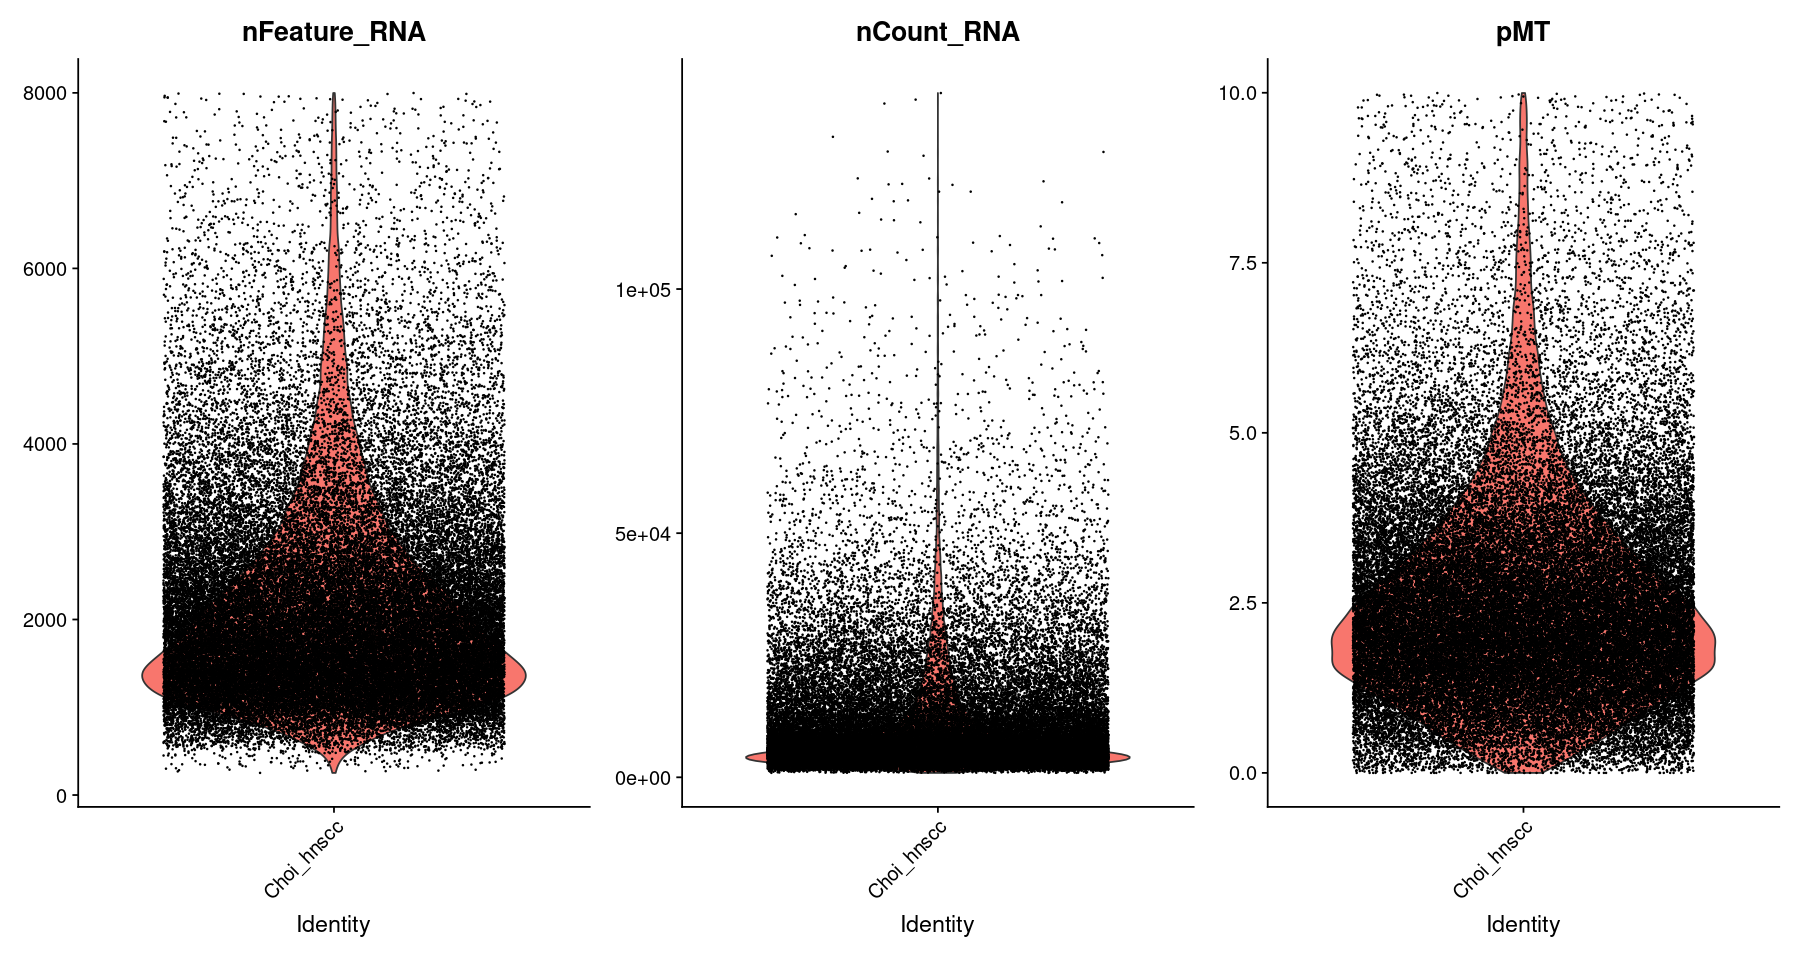

In [13]:
options(repr.plot.width = 15, repr.plot.height = 8)
VlnPlot(seu_obj_filtered, features = c("nFeature_RNA", "nCount_RNA", "pMT"), ncol = 3)

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,9471835,505.9,14688674,784.5,14688674,784.5
Vcells,726428497,5542.3,2213350728,16886.6,2717578888,20733.5


Will not return corrected UMI because residual type is not set to 'pearson'



,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,9549667,510.1,14688674,784.5,14688674,784.5
Vcells,1177147015,8981.0,2656100873,20264.5,2717578888,20733.5


Warning message:
“Invalid name supplied, making object name syntactically valid. New object name is Seurat..ProjectDim.SCT.harmony; see ?make.names for more details on syntax validity”
Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


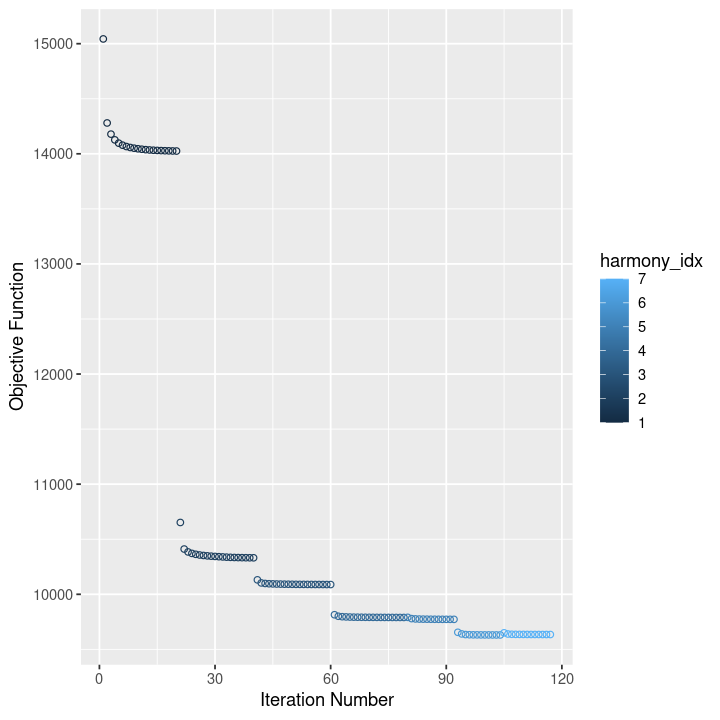

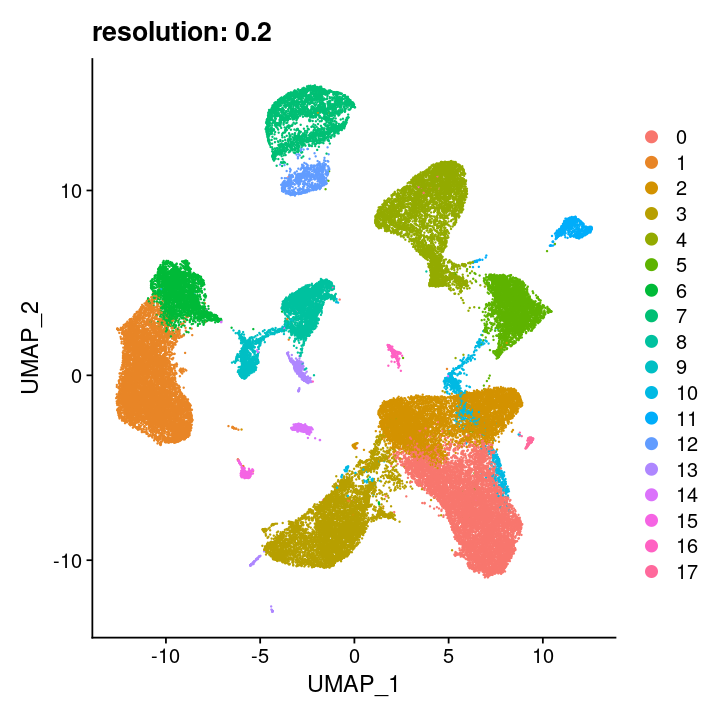

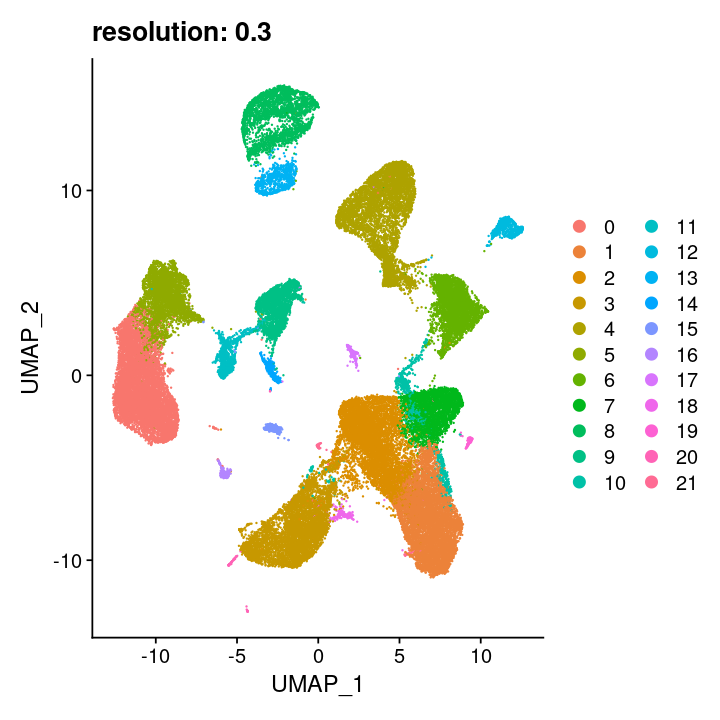

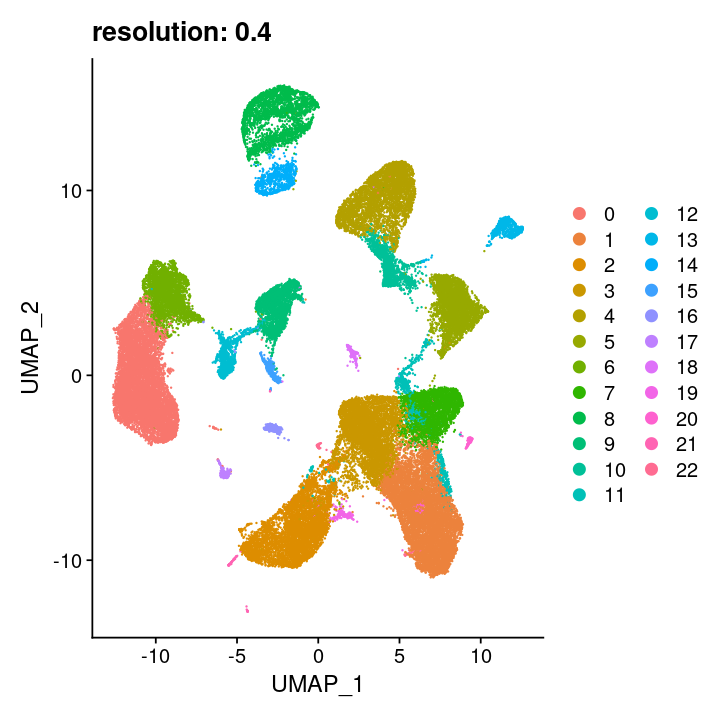

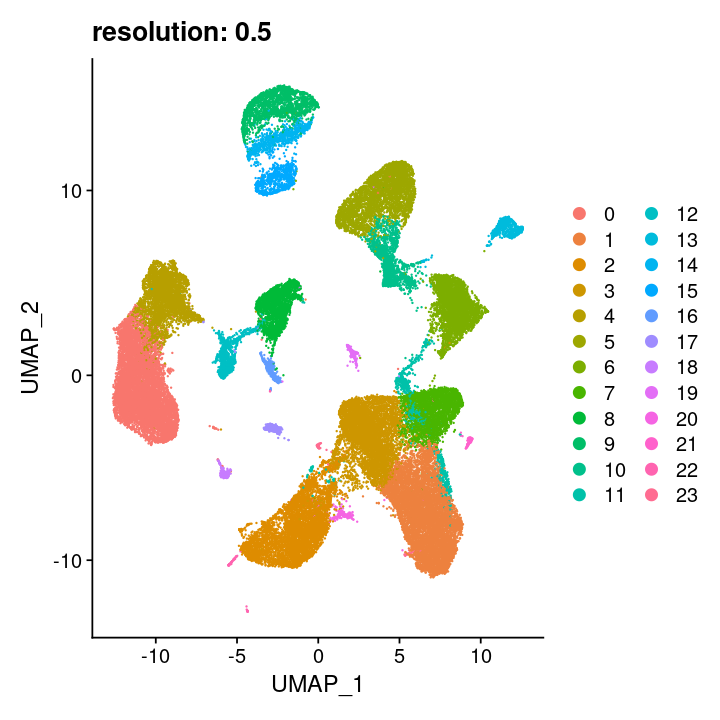

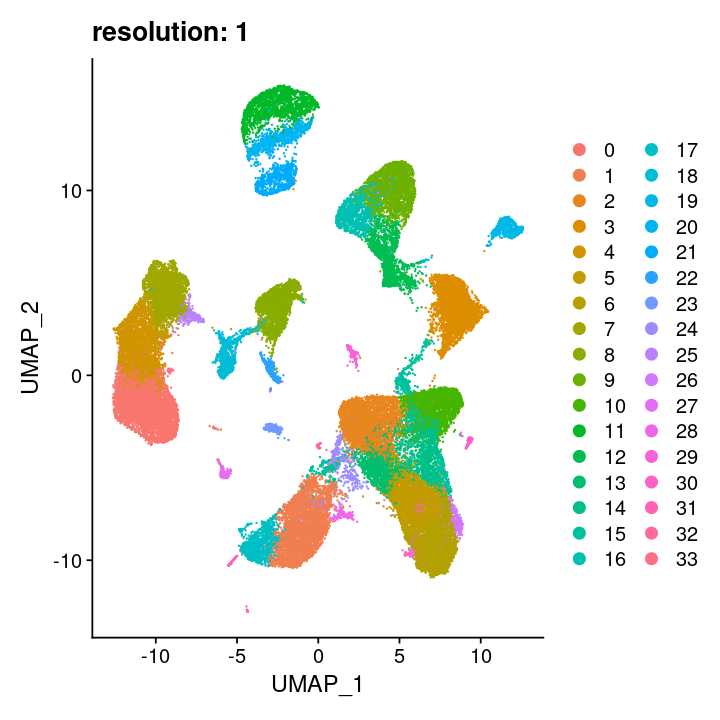

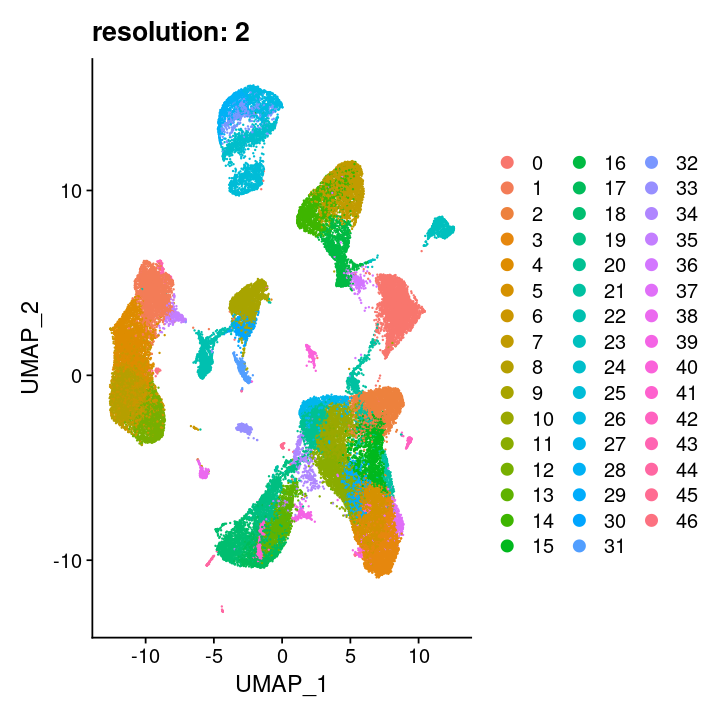

In [14]:
options(repr.plot.width = 6, repr.plot.height = 6)
# Data normalization
gc()
seu_obj_filtered <- SCTransform(seu_obj_filtered, verbose = FALSE, vars.to.regress = c("nCount_RNA", "pMT"), conserve.memory = T)

gc()
# Dimensionality reduction
seu_obj_filtered <- RunPCA(seu_obj_filtered, verbose = FALSE)

seu_obj_filtered <- seu_obj_filtered %>% 
    RunHarmony("patient.id", plot_convergence = TRUE, assay.use = "SCT", verbose = FALSE)

# seu_obj_filtered <- RunUMAP(seu_obj_filtered, reduction = "harmony")
seu_obj_filtered <- seu_obj_filtered %>% 
    RunUMAP(reduction = "harmony", dims = 1:20, verbose = FALSE) %>% 
    FindNeighbors(reduction = "harmony", dims = 1:20, verbose = FALSE)

for (i in c(0.2, 0.3, 0.4, 0.5, 1, 2)) {
  seu_obj_filtered <- FindClusters(seu_obj_filtered, resolution = i, verbose = FALSE)
  print(DimPlot(seu_obj_filtered, reduction = "umap") + labs(title = paste0("resolution: ", i)))
}



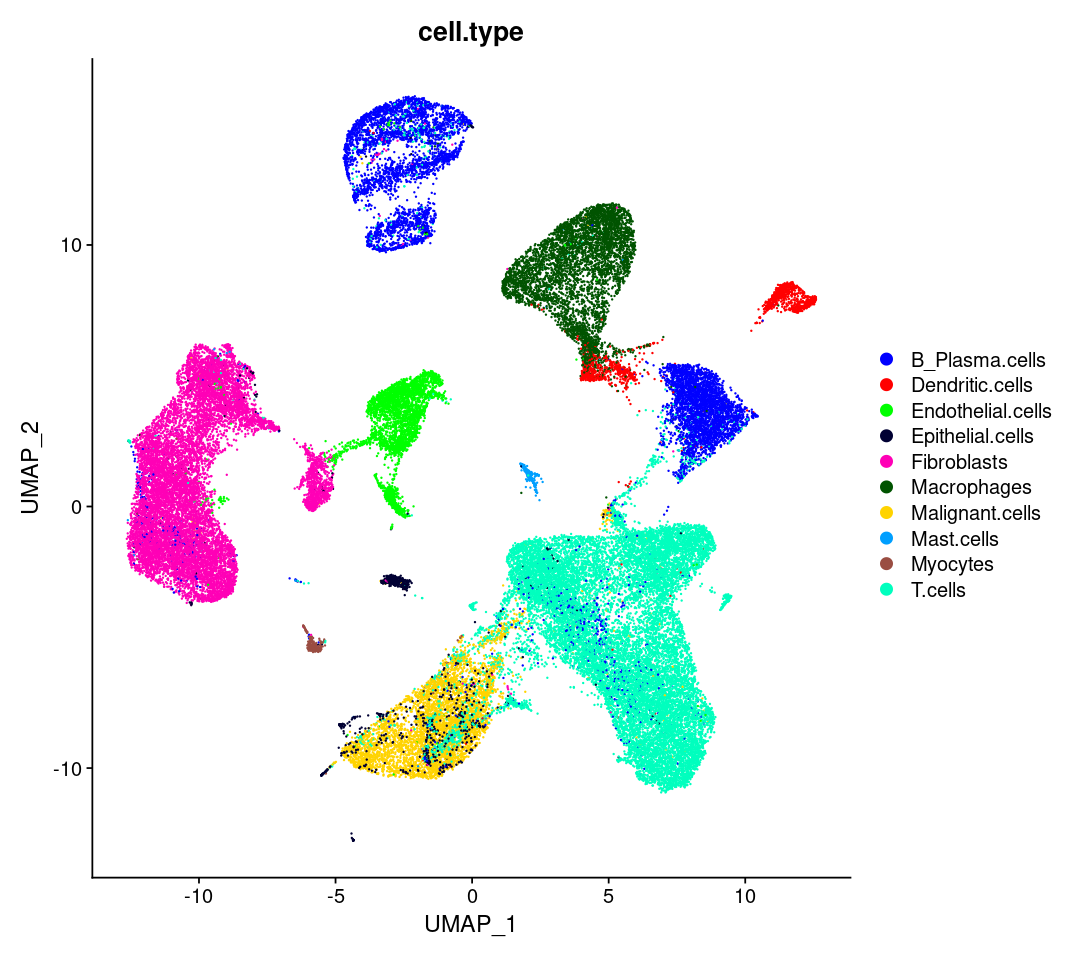

In [15]:
options(repr.plot.width = 9, repr.plot.height = 8)

n_colors <- length(unique(seu_obj_filtered@meta.data$cell.type))
colors <- DiscretePalette(n_colors, palette = "glasbey")
DimPlot(seu_obj_filtered, group.by = "cell.type", label = FALSE,  cols = colors)

In [16]:
saveRDS(seu_obj_filtered, glue('{data.dir}/Choi_hnscc.rds'))
# seu_obj_filtered <- readRDS(glue('{data.dir}/Choi_hnscc.rds'))

In [18]:
unique(seu_obj_filtered$tissue.type)

[1] "CA" "LN" "NL" "LP"

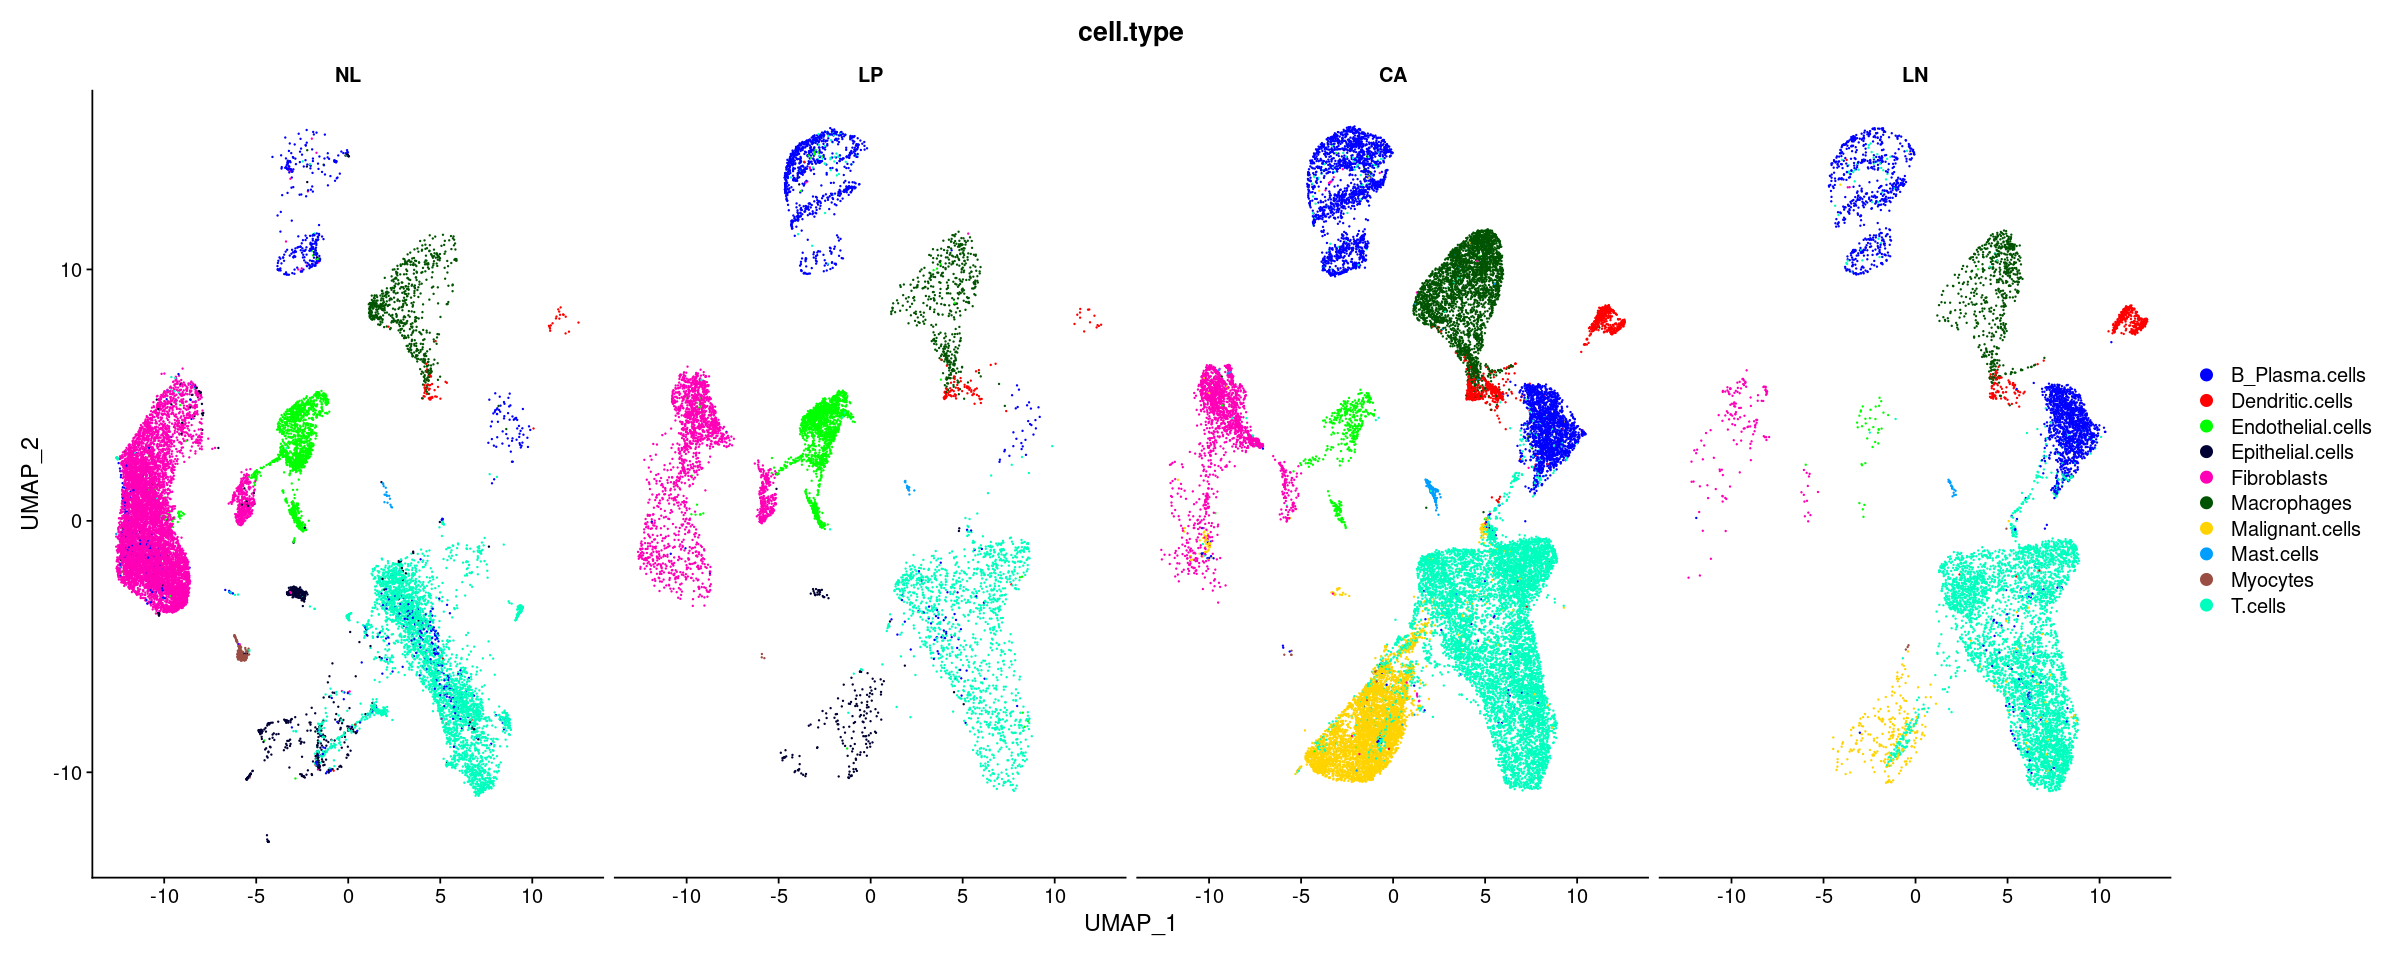

In [19]:
options(repr.plot.width = 20, repr.plot.height = 8)
# tissue.type
# normal tissue (NL, n = 9), leukoplakia (LP, n = 4), primary cancer (CA, n = 20), and metastatic tumors in lymph nodes (LN, n = 4)

seu_obj_filtered$tissue.type <- factor(seu_obj_filtered$tissue.type, levels = c('NL', 'LP', 'CA', 'LN'))
n_colors <- length(unique(seu_obj_filtered@meta.data$cell.type))
colors <- DiscretePalette(n_colors, palette = "glasbey")
DimPlot(seu_obj_filtered, group.by = "cell.type", label = FALSE,  cols = colors, split.by = 'tissue.type')

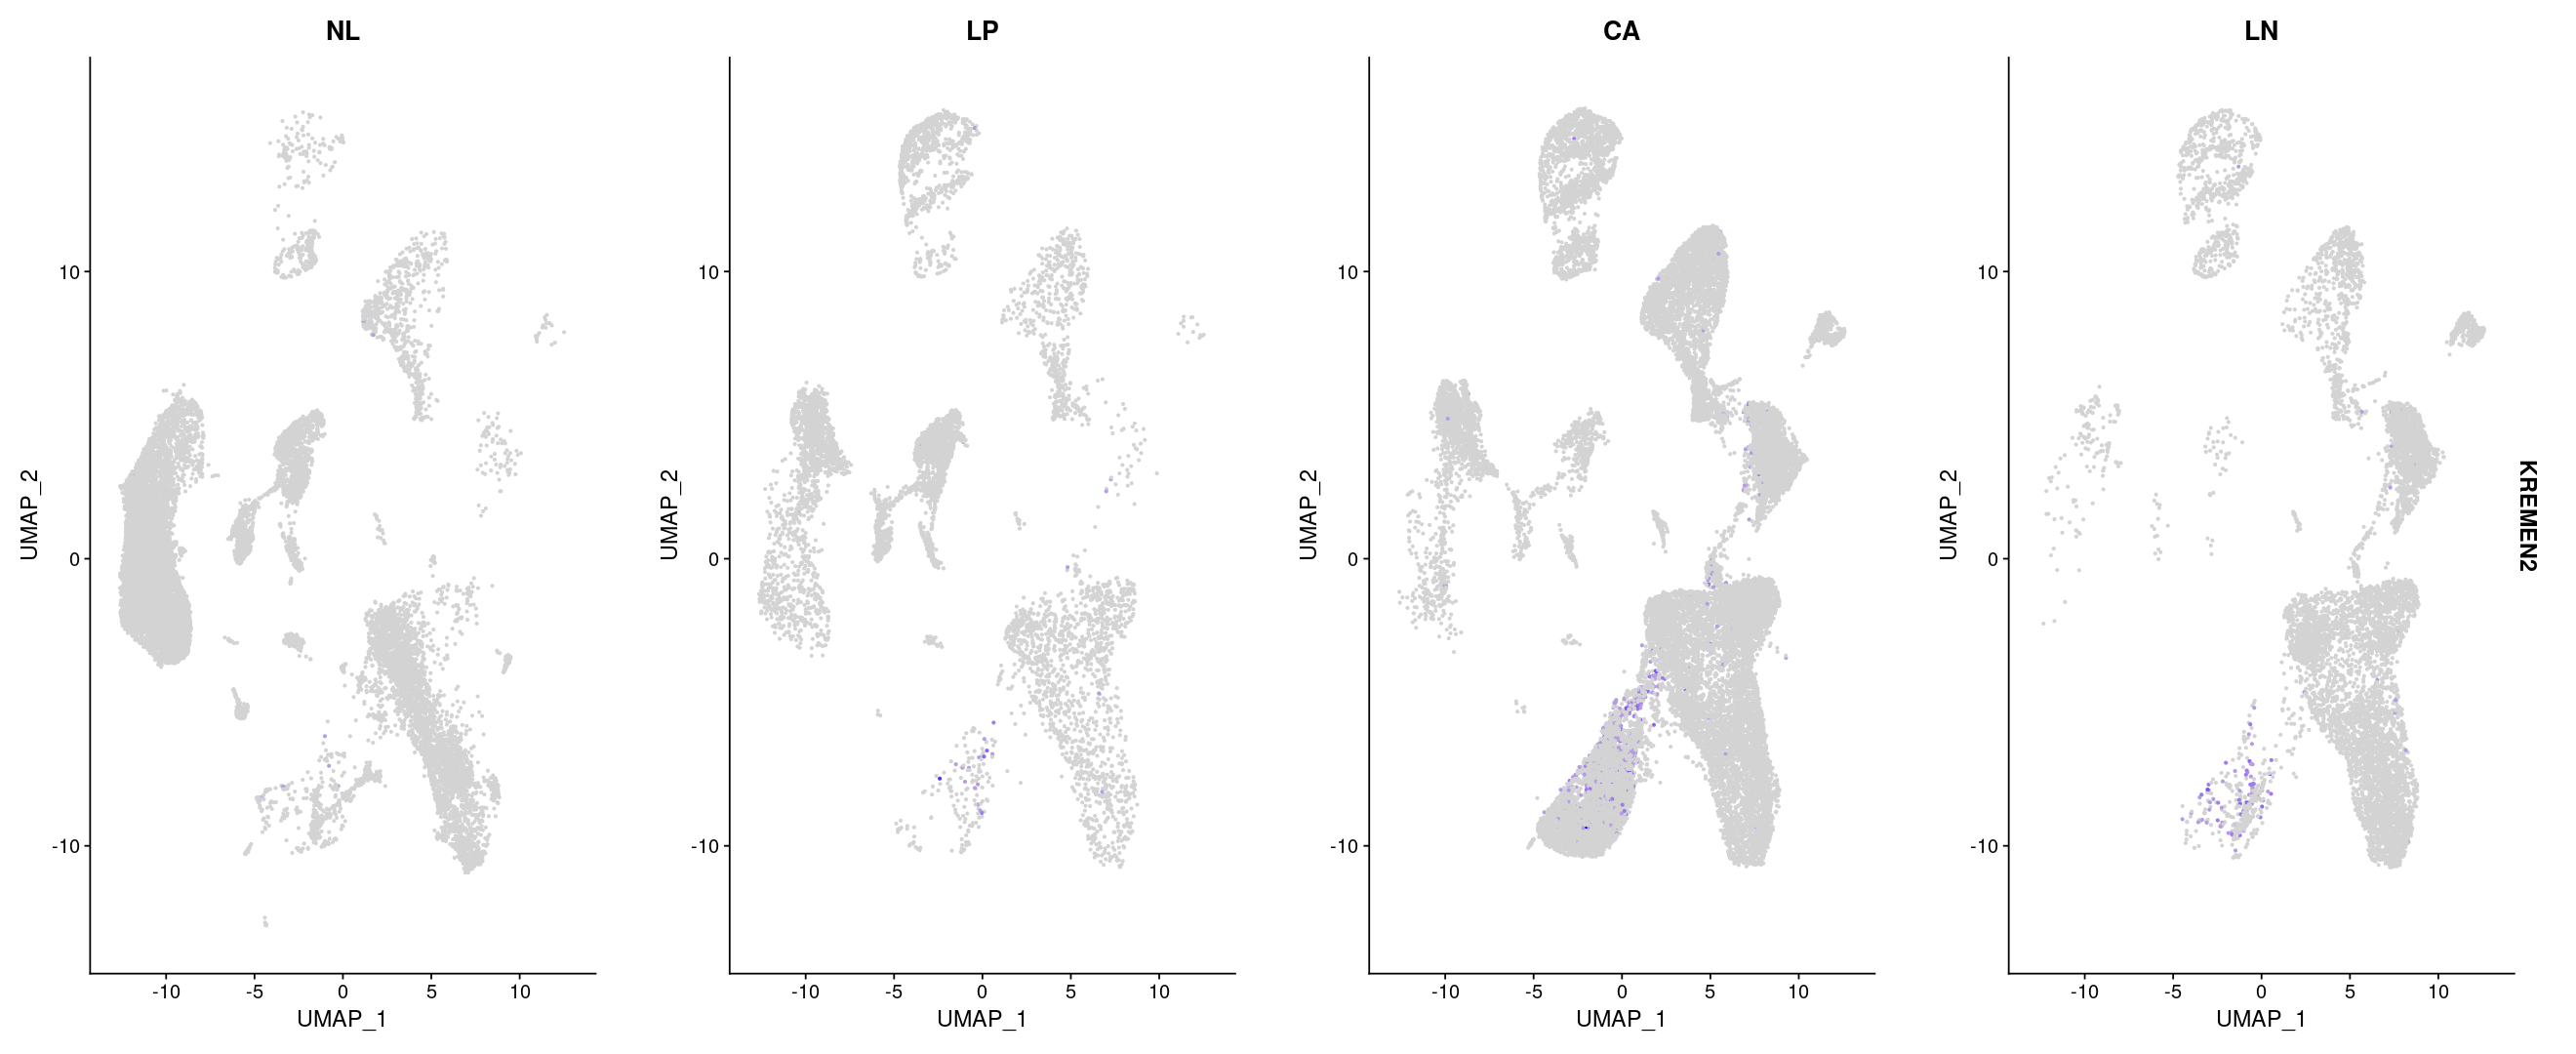

In [20]:
options(repr.plot.width = 22, repr.plot.height = 9)

gene <- 'KREMEN2'
  
FeaturePlot(seu_obj_filtered, features = gene, split.by = 'tissue.type', pt.size = 0.5)
  


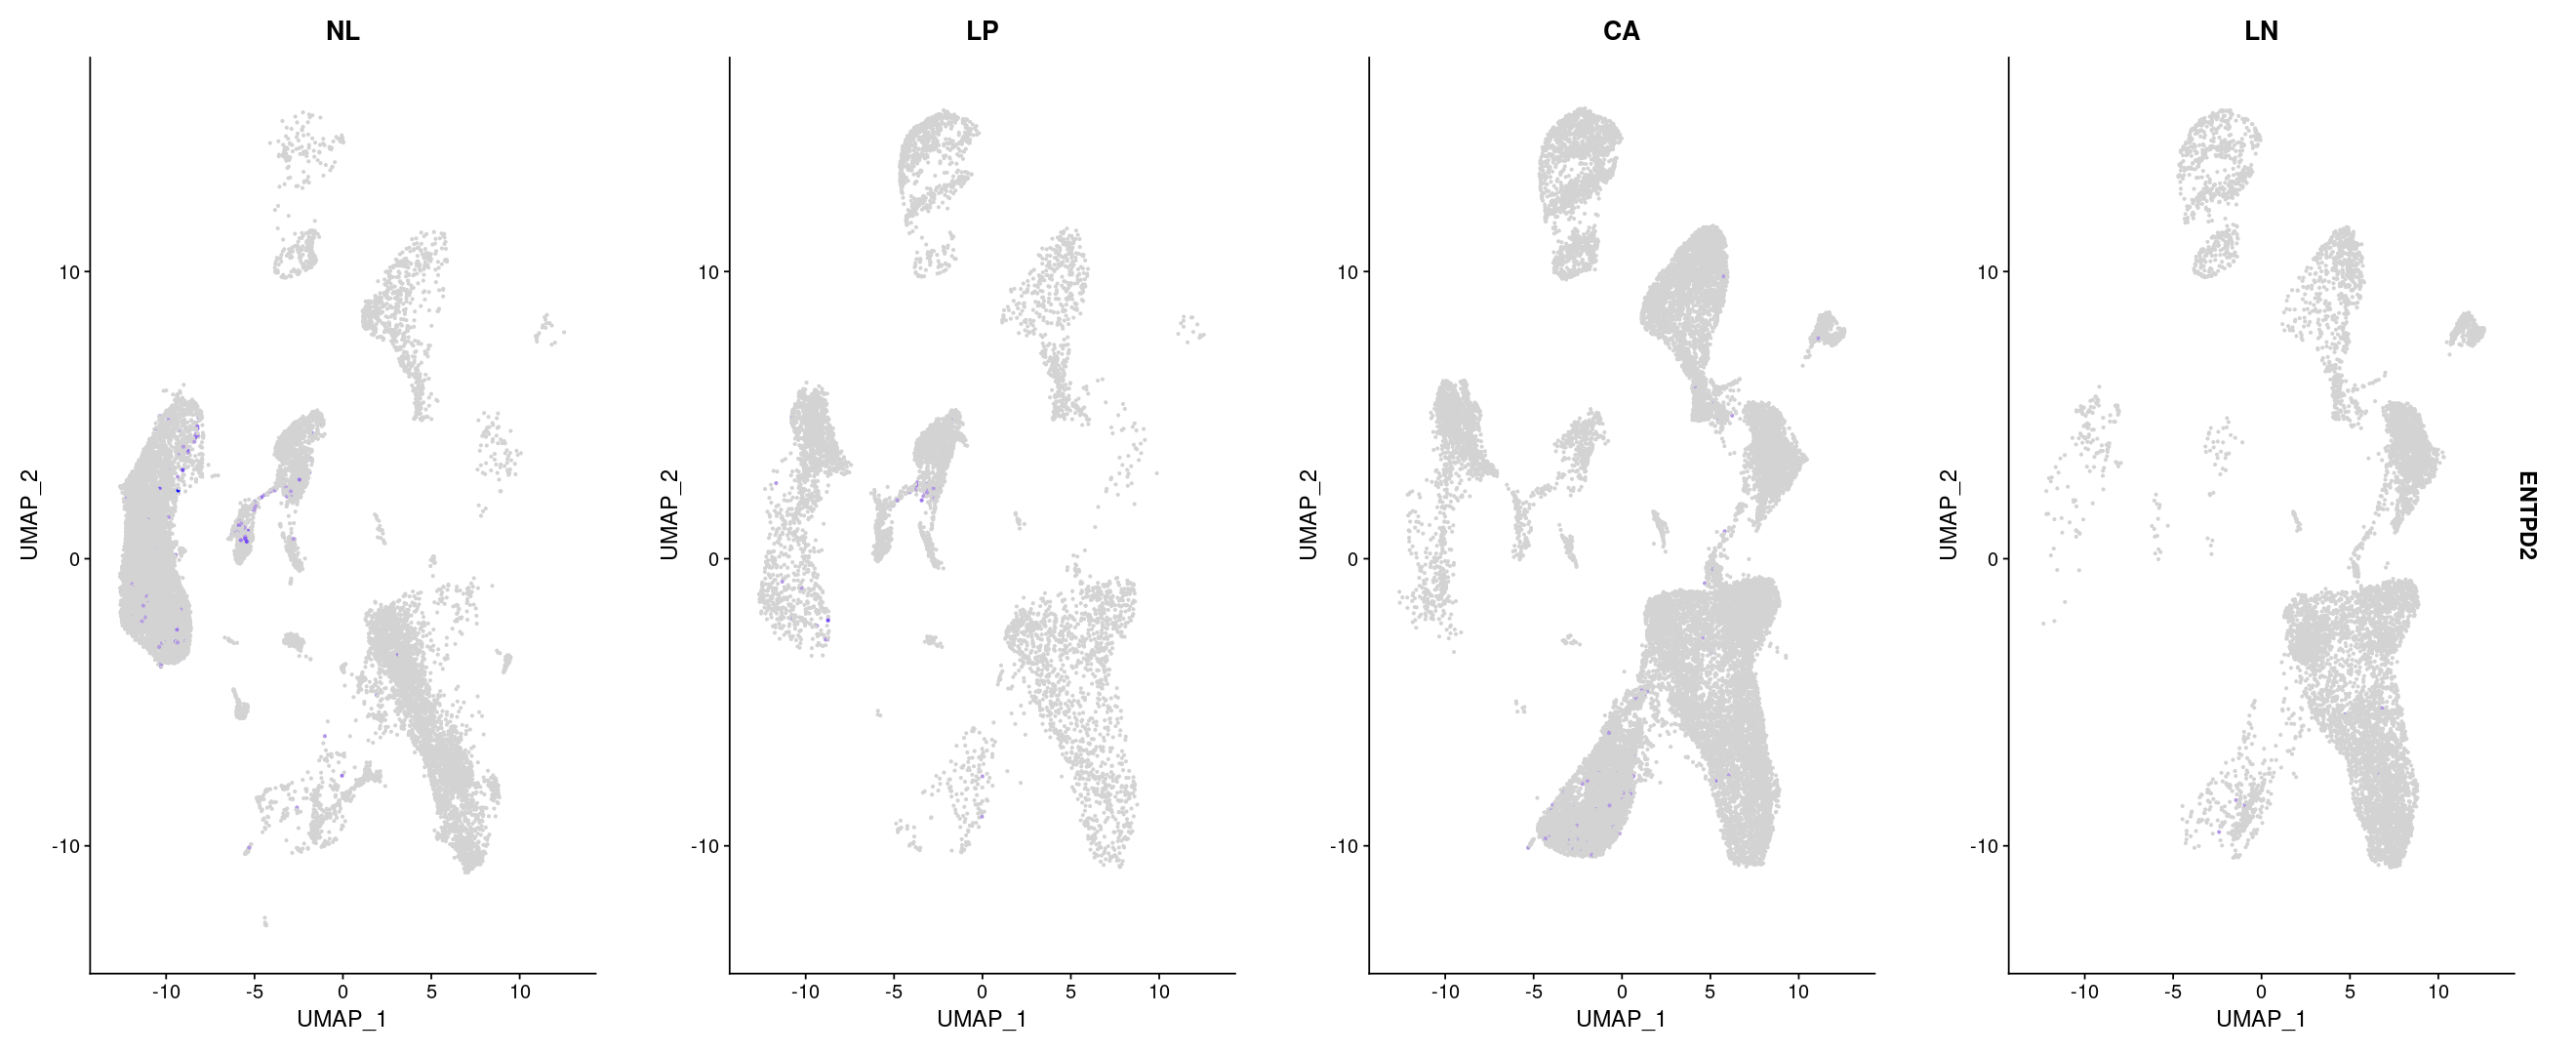

In [21]:
options(repr.plot.width = 22, repr.plot.height = 9)

gene <- 'ENTPD2'
  
FeaturePlot(seu_obj_filtered, features = gene, split.by = 'tissue.type', pt.size = 0.5)